In [1]:
import cv2
import os 
import matplotlib.pyplot as plt
import numpy as np


In [2]:
def load_image(filename, folder="../data"):
    filepath = os.path.join(folder, filename)
    image = cv2.imread(filepath)

    if image is None:
        print(f"No image imported at '{filepath}'.")
    
    return image

def get_rgb_image(image):
    if image is None: 
        return None
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

def get_hsv_image(image):
    if image is None: 
        return None
    return cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

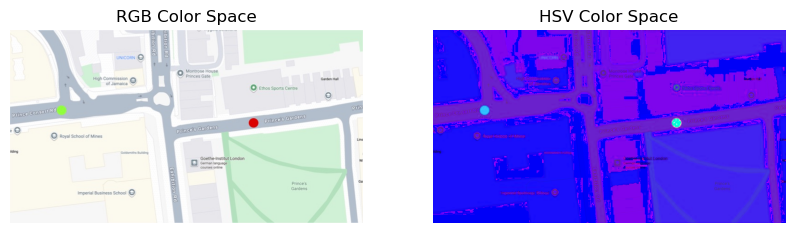

In [3]:
file_name = "CW2Map.jpg"

rawimage = load_image(file_name, folder="../data")
rgbimage = get_rgb_image(rawimage)
hsvimage = get_hsv_image(rawimage)  


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
    
# Plot RGB 
ax1.imshow(rgbimage)
ax1.set_title("RGB Color Space")
ax1.axis('off')

# Plot HSV
ax2.imshow(hsvimage)
ax2.set_title("HSV Color Space")
ax2.axis('off')

plt.show()


In [4]:
#extraction functions 

def extract_road_mask(hsvimage):   
    if hsvimage is None:
        return None
    
    lower_thres_grey = np.array([0, 0, 150])
    upper_thres_grey = np.array([179, 50, 220])
    
    road_mask = cv2.inRange(hsvimage, lower_thres_grey, upper_thres_grey)
    
    return road_mask

def extract_start_mask(rgbimage):
    if rgbimage is None: 
        return None
    
    lower_thres_red = np.array([150, 0, 0])
    upper_thres_red = np.array([255, 100, 100])

    start_mask = cv2.inRange(rgbimage, lower_thres_red, upper_thres_red)

    return start_mask

def extract_end_mask(rgbimage):
    if rgbimage is None: 
        return None
    
    lower_thres_green = np.array([50, 200, 0])
    upper_thres_green = np.array([180, 255, 100])

    goal_mask = cv2.inRange(rgbimage, lower_thres_green, upper_thres_green)

    return goal_mask

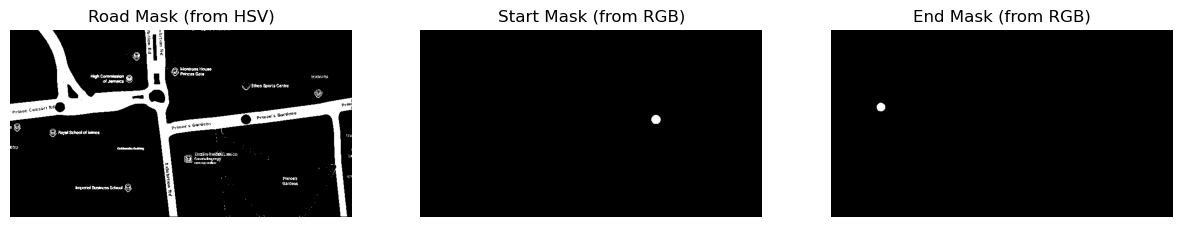

In [5]:
road_mask = extract_road_mask(hsvimage)
start_mask = extract_start_mask(rgbimage)
end_mask = extract_end_mask(rgbimage)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(road_mask, cmap='gray')
axes[0].set_title("Road Mask (from HSV)")
axes[0].axis('off')

axes[1].imshow(start_mask, cmap='gray')
axes[1].set_title("Start Mask (from RGB)")  
axes[1].axis('off')

axes[2].imshow(end_mask, cmap='gray')
axes[2].set_title("End Mask (from RGB)")
axes[2].axis('off')

plt.show()

In [6]:
#Filter out text from the road mask using morphological operations and non road elements using contour filtering

def filter_road_mask(road_mask):
    if road_mask is None:
        return None
    #These remove the text in between the road
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (4, 4)) # 3 had one tiny spot left
    cleaned_mask = cv2.morphologyEx(road_mask, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(cleaned_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    filtered_mask = np.zeros_like(road_mask)

    if contours:
        contours = sorted(contours, key=cv2.contourArea, reverse = True ) #Sort first
        cv2.drawContours(filtered_mask, [contours[0]], -1, 255, -1) #The largest contour is the road
        filtered_mask = cv2.bitwise_and(cleaned_mask, filtered_mask) # Without that it removed also the middle of the roundabout

    return filtered_mask

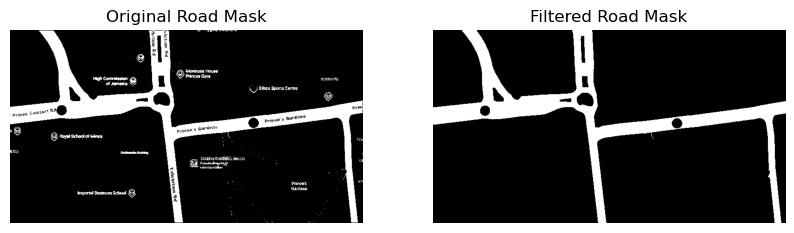

In [7]:
filtered_road_mask = filter_road_mask(road_mask)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(road_mask, cmap='gray')
axes[0].set_title("Original Road Mask")
axes[0].axis('off')

axes[1].imshow(filtered_road_mask, cmap='gray')
axes[1].set_title("Filtered Road Mask")
axes[1].axis('off')
plt.show()

In [8]:
#Get centers of the markers 

def get_marker_centers(marker_mask):
    if marker_mask is None: 
        return None
    
    contours, _ = cv2.findContours(marker_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours: 
        return None
    
    contours = sorted(contours, key=cv2.contourArea, reverse=True) 
    marker = contours[0]

    (x, y), radius = cv2.minEnclosingCircle(marker)
    center = (int(x), int(y))

    return center

In [9]:
start_coordinates = get_marker_centers(start_mask)
end_coordinates = get_marker_centers(end_mask)

print(f"Start coordinates (red): {start_coordinates}")
print(f"End coordinates (green): {end_coordinates}")

Start coordinates (red): (526, 200)
End coordinates (green): (110, 173)


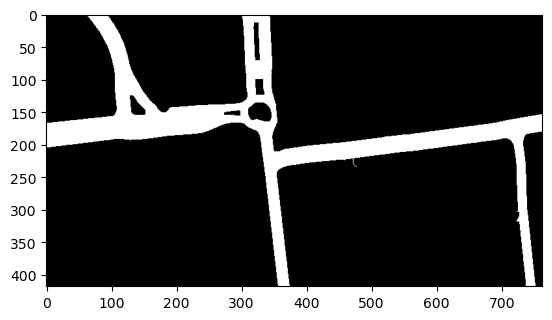

In [10]:
if start_coordinates: #Draw white circle around start and end
    cv2.circle(filtered_road_mask, start_coordinates, 13, 255, -1) 
if end_coordinates:
    cv2.circle(filtered_road_mask, end_coordinates, 14, 255, -1)

plt.imshow(filtered_road_mask, cmap='gray')
plt.show()

Centers are not perfect yet. Generate callable python file from this. 

In [12]:
# Get road width of thinnest part (straight after roundabout) 
import math 

p1 = (294.0, 154.8)
p2 = (294.4, 165.5)

road_width = math.dist(p1, p2)
print(f"Road width at thinnest part: {road_width:.2f} (in pixels)")
robot_size = 0.25 * road_width 
print(f"Robot size (25% of road width): {robot_size:.2f} (in pixels)")

Road width at thinnest part: 10.71 (in pixels)
Robot size (25% of road width): 2.68 (in pixels)


In [13]:
#Shrink road by 2 pixels on each side to ensure robot fitrs

def apply_safety_margin(road_mask, margin = 2):
    if road_mask is None:
        return None
    
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (margin*2+1, margin*2+1))

    safe_mask = cv2.erode(road_mask, kernel, iterations=1)

    return safe_mask

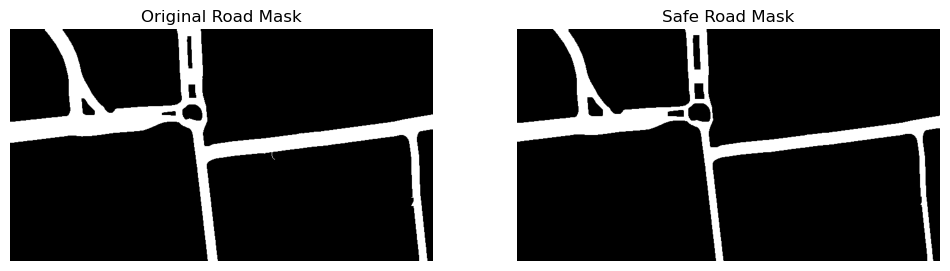

In [14]:
safe_road_mask = apply_safety_margin(filtered_road_mask, margin=2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.imshow(filtered_road_mask, cmap='gray')
ax1.set_title('Original Road Mask')
ax1.axis('off')
ax2.imshow(safe_road_mask, cmap='gray')
ax2.set_title('Safe Road Mask')
ax2.axis('off')
plt.show()